In [1]:
import networkx
import pandas as pd
# pd.set_option('max_rows', 400)
import matplotlib.pyplot as plt

In [2]:
# 5.1 : Reading graph data from a CSV file

got_df = pd.read_csv('got-edges.csv')
got_df.head()

,Source,Target,Weight
0,Aemon,Grenn,5
1,Aemon,Samwell,31
2,Aerys,Jaime,18
3,Aerys,Robert,6
4,Aerys,Tyrion,5


{('Aemon', 'Grenn'): Text(0.20670641671316825, -0.3645046657800681, '5'),
 ('Aemon', 'Samwell'): Text(0.20219378109820463, -0.25960546192187883, '31'),
 ('Aemon', 'Jon'): Text(0.17053661607231785, -0.2219792693885797, '30'),
 ('Aemon', 'Robert'): Text(-0.0007913881358985186, -0.1985106955375212, '4'),
 ('Aemon', 'Stannis'): Text(0.06695334255399521, -0.19356494450197204, '4'),
 ('Grenn', 'Eddison'): Text(0.42363545667449043, -0.38511798943888265, '8'),
 ('Grenn', 'Jon'): Text(0.3020378622565836, -0.27952033078449, '25'),
 ('Grenn', 'Samwell'): Text(0.3336928184743062, -0.31714135949578226, '43'),
 ('Samwell', 'Bran'): Text(0.34705495087346394, -0.07363143508700021, '11'),
 ('Samwell', 'Jojen'): Text(0.49051479456573355, -0.11708396245770292, '11'),
 ('Samwell', 'Jon'): Text(0.2975238903849917, -0.17462063062165856, '52'),
 ('Samwell', 'Meera'): Text(0.43566456724617075, -0.1397980503191164, '7'),
 ('Samwell',
  'Melisandre'): Text(0.2402836896654299, -0.27668783783861817, '5'),
 ('Samw

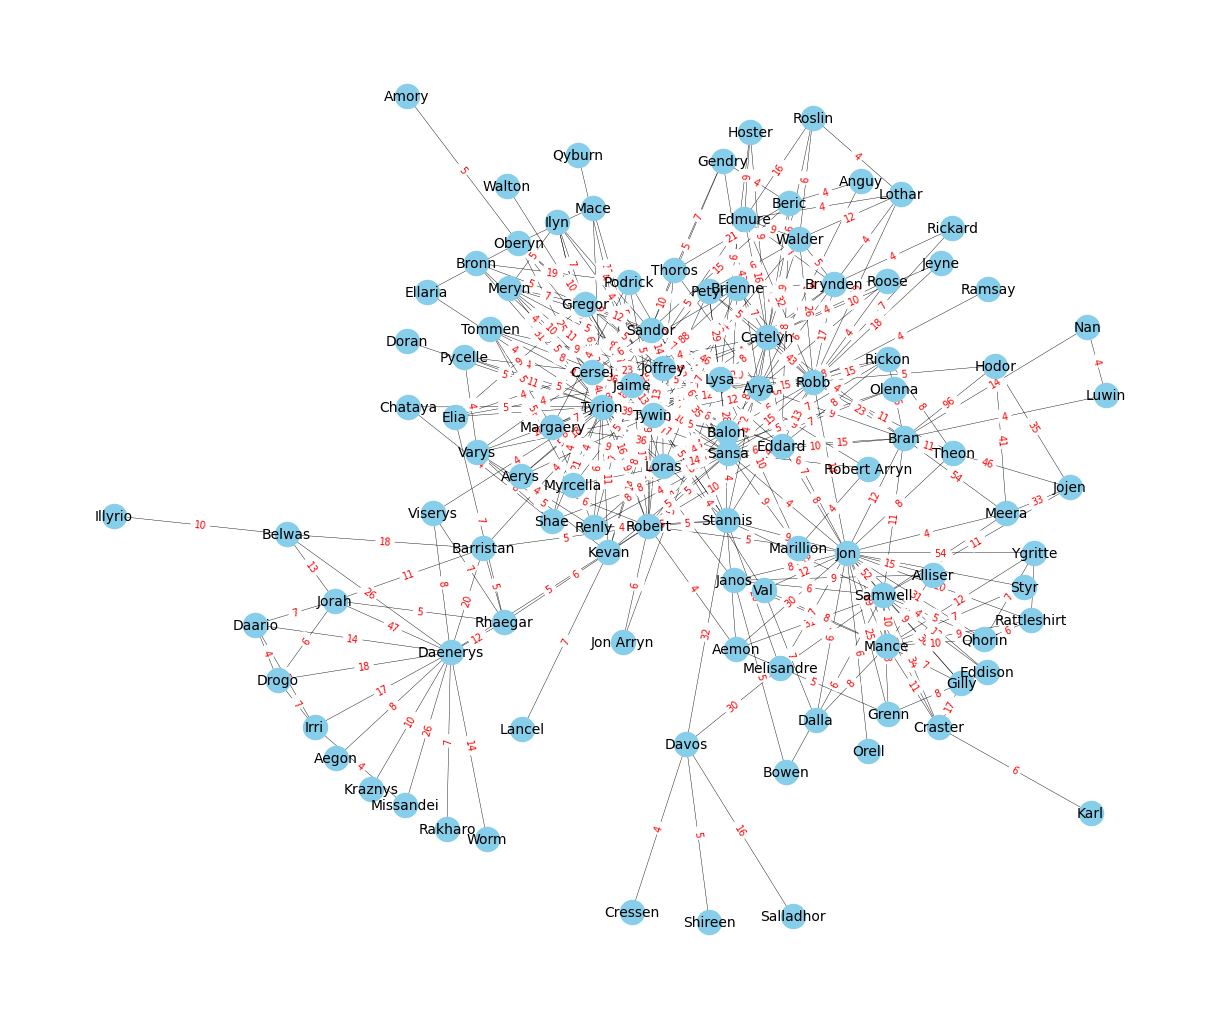

In [4]:
# 5.2 Create graph

G = networkx.from_pandas_edgelist(got_df, 'Source', 'Target', 'Weight')
networkx.write_graphml(G, 'GOT-network.graphml')

plt.figure(figsize=(12,10))

pos = networkx.kamada_kawai_layout(G)
# pos = networkx.spring_layout(G, seed=100)
#pos = networkx.circular_layout(G)
networkx.draw(G, with_labels=True, pos=pos, node_color='skyblue', width=.3, font_size=10)
networkx.draw_networkx_edge_labels(G, pos=pos, edge_labels=networkx.get_edge_attributes(G, 'Weight'), font_color='red', font_size=7)                       

In [5]:
# 5.3 Stevilo povezav osebe / Who has the most number of connections in the network?
networkx.degree(G)


DegreeView({'Aemon': 5, 'Grenn': 4, 'Samwell': 15, 'Aerys': 4, 'Jaime': 24, 'Robert': 18, 'Tyrion': 36, 'Tywin': 22, 'Alliser': 3, 'Mance': 12, 'Amory': 1, 'Oberyn': 7, 'Arya': 19, 'Anguy': 2, 'Beric': 6, 'Bran': 14, 'Brynden': 8, 'Cersei': 20, 'Gendry': 4, 'Gregor': 12, 'Joffrey': 18, 'Jon': 26, 'Rickon': 6, 'Roose': 4, 'Sandor': 13, 'Thoros': 5, 'Balon': 6, 'Loras': 9, 'Belwas': 4, 'Barristan': 6, 'Illyrio': 1, 'Hodor': 4, 'Jojen': 4, 'Luwin': 2, 'Meera': 5, 'Nan': 2, 'Theon': 4, 'Brienne': 7, 'Bronn': 4, 'Podrick': 5, 'Lothar': 5, 'Walder': 8, 'Catelyn': 18, 'Edmure': 8, 'Hoster': 3, 'Jeyne': 2, 'Lysa': 10, 'Petyr': 7, 'Robb': 25, 'Roslin': 4, 'Sansa': 26, 'Stannis': 14, 'Elia': 5, 'Ilyn': 6, 'Meryn': 7, 'Pycelle': 4, 'Shae': 5, 'Varys': 7, 'Craster': 5, 'Karl': 1, 'Daario': 4, 'Drogo': 4, 'Irri': 4, 'Daenerys': 14, 'Aegon': 1, 'Jorah': 6, 'Kraznys': 1, 'Missandei': 2, 'Rakharo': 1, 'Rhaegar': 6, 'Viserys': 3, 'Worm': 1, 'Davos': 5, 'Cressen': 1, 'Salladhor': 1, 'Eddard': 12, 'Eddis

In [ ]:
degrees = dict(networkx.degree(G))
networkx.set_node_attributes(G, name='degree', values=degrees)

degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df

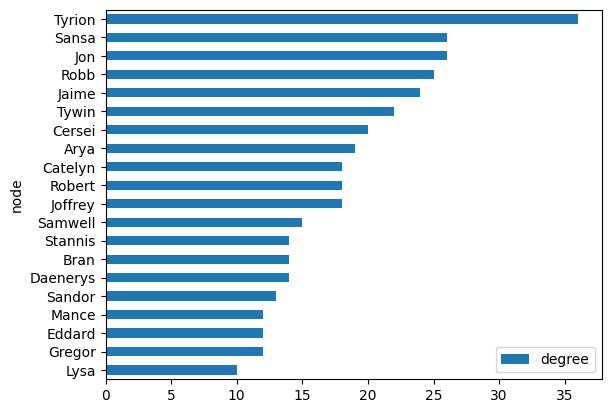

In [8]:
num_nodes = 20
df_sorted = degree_df.sort_values(by='degree', ascending=False)
df_sorted[:num_nodes].plot(x='node', y='degree', kind='barh').invert_yaxis()

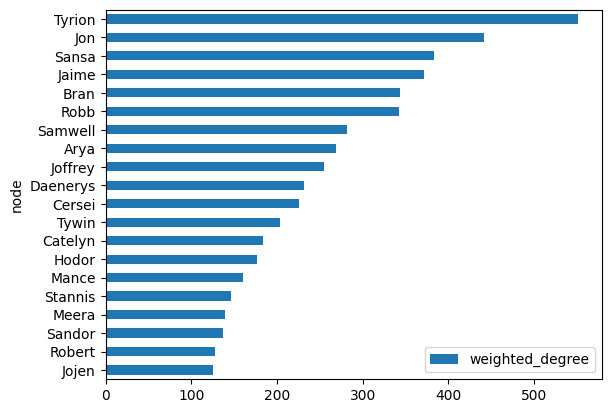

In [12]:
# 5.6 Weighted degree - upošteva tudi težo povezav (število skupnih prizadevanj, skupnih dogodkov, ipd.)
networkx.degree(G, weight='Weight')

weighted_degrees = dict(networkx.degree(G, weight='Weight'))
networkx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)

degree_df['weighted_degree'] = degree_df['node'].map(weighted_degrees)
# degree_df
# Izrisi graf
df_sorted = degree_df.sort_values(by='weighted_degree', ascending=False)
df_sorted[:num_nodes].plot(x='node', y='weighted_degree', kind='barh').invert_yaxis()


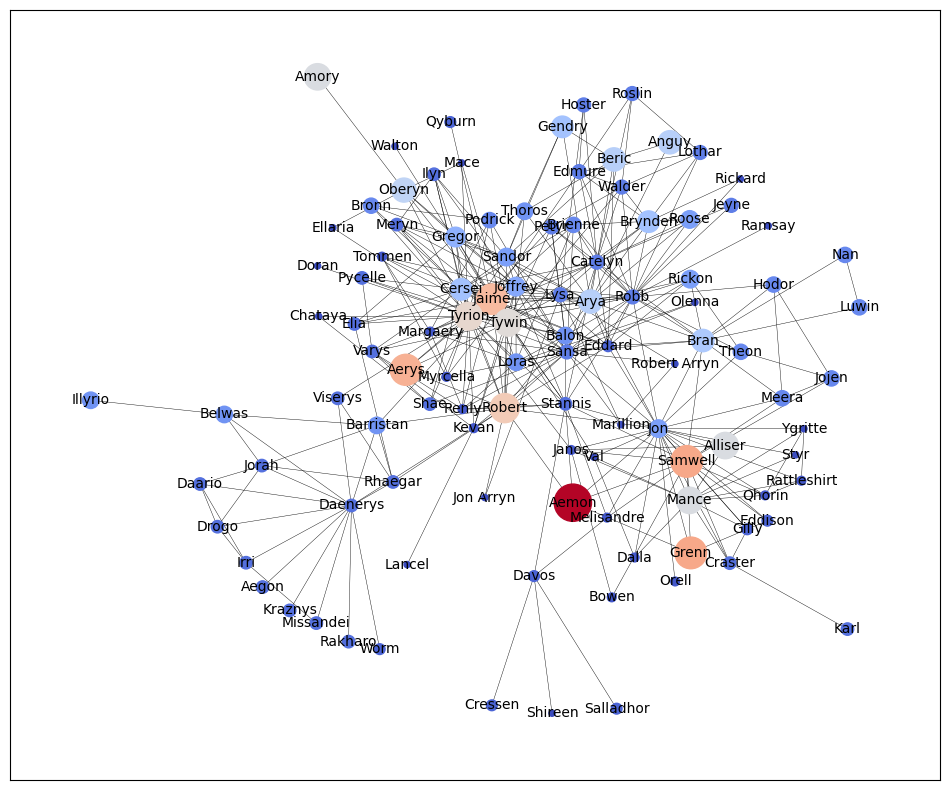

In [17]:
# 5.7
plt.figure(figsize=(12,10))
networkx.draw_networkx(G, pos=pos, with_labels=True, node_color=degree_df['degree'],
                       node_size=degree_df['degree']*20,
                       width=.3, font_size=10, cmap='coolwarm')




{'Aemon': 0.004622508177397137, 'Grenn': 5.989817310572027e-05, 'Samwell': 0.03227262859511145, 'Aerys': 0.0, 'Jaime': 0.09994344156136246, 'Robert': 0.2094523840293194, 'Tyrion': 0.19791284320277353, 'Tywin': 0.06553840423231058, 'Alliser': 0.0, 'Mance': 0.007275961371756524, 'Amory': 0.0, 'Oberyn': 0.01958014232946847, 'Arya': 0.07960711308183888, 'Anguy': 0.0, 'Beric': 0.0006091214266627511, 'Bran': 0.06301659941786954, 'Brynden': 0.004727134574764742, 'Cersei': 0.02674643287824232, 'Gendry': 0.0, 'Gregor': 0.005879915417737236, 'Joffrey': 0.025434099443917696, 'Jon': 0.22996466368473173, 'Rickon': 0.0007626320968639029, 'Roose': 0.0002629599012559427, 'Sandor': 0.014162278987154626, 'Thoros': 0.0019261823273239152, 'Balon': 0.0006281164805527878, 'Loras': 0.003780752291533962, 'Belwas': 0.018867924528301886, 'Barristan': 0.04011407489067884, 'Illyrio': 0.0, 'Hodor': 0.0021937273446681065, 'Jojen': 0.0004064518889316733, 'Luwin': 0.0, 'Meera': 0.0019922569692430686, 'Nan': 0.0, 'The

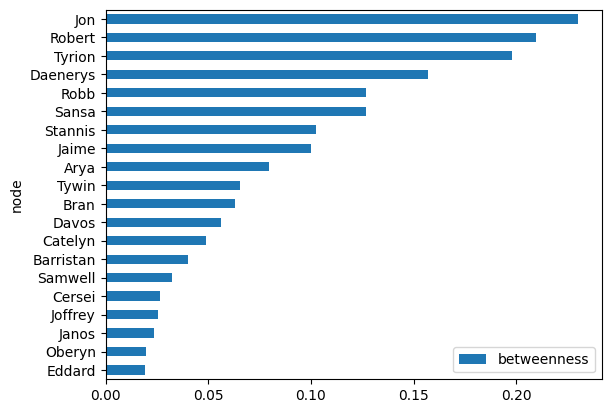

In [21]:
# 5.8
# Who connects the most other nodes in the network?
# Betweenness centrality - meri, koliko krat je vozlišče na najkrajši poti med dvema drugima vozliščema. Višja vrednost pomeni, da vozlišče deluje kot pomemben posrednik ali "most" v omrežju.

betweenness_centrality = networkx.betweenness_centrality(G)
print(betweenness_centrality)

degree_df['betweenness'] = degree_df['node'].map(betweenness_centrality)

degree_df
# Izrisi graf (barh)
df2 = degree_df.sort_values(by='betweenness', ascending=False)[:num_nodes]
df2.plot(x='node', y='betweenness', kind='barh').invert_yaxis()



In [22]:
# 5.9 Communities - skupnosti v omrežju
from networkx.algorithms import community

# Find communities in the graph using the greedy modularity maximization algorithm

communities = community.greedy_modularity_communities(G)   #weight='Weight')   #
communities

[frozenset({'Aerys',
            'Amory',
            'Balon',
            'Bronn',
            'Chataya',
            'Doran',
            'Elia',
            'Ellaria',
            'Gregor',
            'Ilyn',
            'Jaime',
            'Joffrey',
            'Kevan',
            'Lancel',
            'Loras',
            'Mace',
            'Margaery',
            'Meryn',
            'Myrcella',
            'Oberyn',
            'Olenna',
            'Podrick',
            'Pycelle',
            'Qyburn',
            'Renly',
            'Sandor',
            'Shae',
            'Tommen',
            'Tyrion',
            'Tywin',
            'Varys',
            'Walton'}),
 frozenset({'Aemon',
            'Alliser',
            'Bowen',
            'Craster',
            'Cressen',
            'Dalla',
            'Davos',
            'Eddison',
            'Gilly',
            'Grenn',
            'Hodor',
            'Janos',
            'Jojen',
            'Jon',
     

In [23]:
# 5.10
# Make a dictionary by looping through the communities and, for each member of the community, adding their community number
community_dict = {}
for i, community in enumerate(communities):
    for member in community:
        community_dict[member] = i
        

degree_df['community'] = degree_df['node'].map(community_dict)
degree_df


,node,degree,weighted_degree,betweenness,community
6,Tyrion,36,551,0.197913,0
21,Jon,26,442,0.229965,1
50,Sansa,26,383,0.126720,2
48,Robb,25,342,0.126964,2
4,Jaime,24,372,0.099943,0
...,...,...,...,...,...
73,Cressen,1,4,0.000000,1
74,Salladhor,1,16,0.000000,1
78,Qyburn,1,11,0.000000,0
88,Orell,1,6,0.000000,1


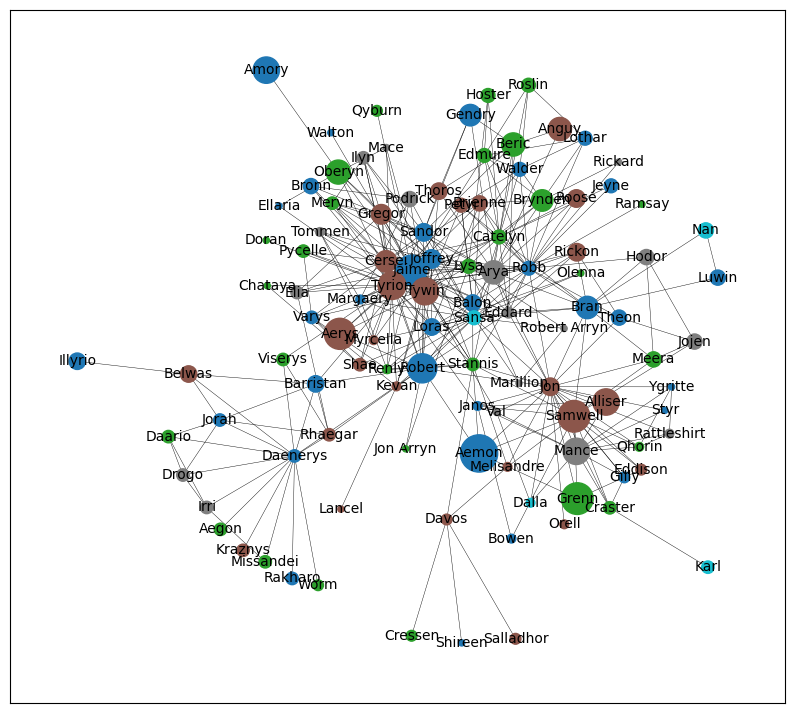

In [24]:
plt.figure(figsize=(10,9))
networkx.draw_networkx(G, pos=pos, with_labels=True, node_color=degree_df['community'],
                       node_size=degree_df['degree']*20,
                       width=.3, font_size=10, cmap='tab10')